# Auto-encoding variable bayes

Adapted from https://github.com/pytorch/examples/tree/main/vae

## The Experiment

_this original bit of Science<sup>tm</sup> was done by Rachel Lowe, February 2026_

### What's being tested?
This is an ill-advised attempt at evaluating how well stochastic rounding works in the context of PyTorch.

The only stochastic rounding implementation within the context of ML-related stuff I could find for Python
was the Torchastic library (https://pypi.org/project/torchastic/), which provides a PyTorch optimizer
which allows one to train a model using stochastically-rounded `bfloat16`s.

So, this notebook attempts to evaluate the performance of 'using stochastic rounding'
(using torchastic's stochastic AdamW optimizer on a `bfloat16` model)
against 'not using stochastic rounding' (using the regular AdamW optimizer on a `bfloat16` model)
and 'not rounding' (using the regular AdamW optimizer on a `float32` model).
As a baseline, I will also be running the default configuration of the model as well (Adam optimizer, `float32`)


### How is it being tested?

This notebook contains a re-implementation of one of the pytorch example models - specifically,
the bayesian variational auto-encoder example model (https://github.com/pytorch/examples/tree/main/vae),
but with a few tweaks to record some performance metrics and produce some flashy graphs.
However, the core functionality of the model is unchanged.

What does this model do? It attempts to run a variational auto-encoder on the mnist dataset.
This attempts to interpret samples from the dataset by discovering their latent properties.
This can then be used to test the model by seeing if it can reconstruct inputs via their latent
properties (model identifies latent properties of input, produces output from model's knowledge of
those latent properties, evaluate how accurate the reconstruction was), and then can be used to
generate new outputs which (theoretically) should resemble the originals by plugging in arbitrary data.

#### Why am I testing it like this?
* Using this premade model (specifically, a model which is actively promoted as one of the PyTorch example
models: https://docs.pytorch.org/examples/) means that one can safely assume that the underlying code being used
for this experiment is somewhat sensibly-implemented and not entirely unlike the sort of code which one would
expect to see in the real world - moreso than would be possible by bodging a new model together from scratch
  * In other words - it ensures we have a baseline which won't be entirely terrible.
* I couldn't find much explicitly discussing the use of stochastic rounding in this context (VAEs) during my
cursory glance at the literature surrounding stochastic rounding - so this may or may not count as
a *totally* groundbreaking new bit of research ~~yeah right, sure it is~~
  * beats just 'finding someone else's experiment and re-running that and re-reporting their results'
* Saves me having to get used to the entire Julia ecosystem from scratch in order to run a very simple
silly little experiment with silly graphs and such ~~vs code my detested~~

~~And is this bit of totally original Science<sup>tm</sup> ultimately just going to be a waste of time and
electricity and contribute absolutely nothing of value to anyone? Yes!~~


## Hypotheses

* **Hypothesis 1** - The version of the bfloat16 model _without_ stochastic rounding will have worse performance than the bfloat16 version _with_ stochastic rounding (evaluated by test data in final epoch)
* **Hypothesis 2** The bfloat16 models will have faster training times than the float32 models.
* **Hypothesis 3** The stochastic bfloat16 model's test set loss will be in line with the float32 models
  * **3.1** stochastic bfloat16 loss will be no more than 1% higher than the highest loss of the float32 models
  * **3.2** stochastic bfloat16 loss will be closer to the average float32 loss than the non-stochastic bfloat16 loss


In [1]:
from __future__ import print_function
import argparse
import pickle
import random
import sys

import torch
import torch.utils.data
import torchvision.utils
from sympy import true
from torch import nn, optim, Tensor
from torch.distributed.nn import all_to_all

from torch.nn import functional as F
from torch.optim import Optimizer
from torchvision import datasets, transforms
from torchvision.io import decode_image
from torchvision.utils import save_image
import numpy as np

import torchastic
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

from cycler import cycler, Cycler

from numbers import Number

from typing import NoReturn, Final, Protocol, TypedDict, Literal, Union, ClassVar, FrozenSet, Generic, TypeVar, Any,Optional

from collections.abc import Sequence, Iterator, Iterable, Callable

import dataclasses
from dataclasses import dataclass

from time import perf_counter

import json

from functools import cached_property

%matplotlib notebook


Hyper-parameters for the experiment

In [2]:

batch_size: int = 128
"""batch size for training (default: 128)"""

epochs: int = 10
"""number of epochs to train (default: 10)"""
_use_accel: bool = True
"""should accelerator be enabled"""
seed: int = 1
"""rng seed (default: 1)"""
log_interval: int = 1000
"""how many batches to wait before logging training status (default: 10)"""

iterations: int = 10
"""how many iterations we'll test for each model"""

max_iters_no_accel: int = 3
"""if this is being run on CPU, let's not use more than 3 iterations, otherwise we will be waiting for A Very Long Time."""

use_accel: bool = _use_accel and torch.accelerator.is_available()

torch.manual_seed(seed)

if use_accel:
    device = torch.accelerator.current_accelerator()
    print(f"Using device: {device}")
else:
    device = torch.device("cpu")
    print(f"Using device: {device}")

if device.type == "cpu":
    if iterations > max_iters_no_accel:
        iterations = max_iters_no_accel
        print(f"\tReducing iterations to {iterations}, due to this being run on CPU (it will be slow!)")

#print(f"Using device: {device}")

Using device: cuda


<IPython.core.display.Javascript object>

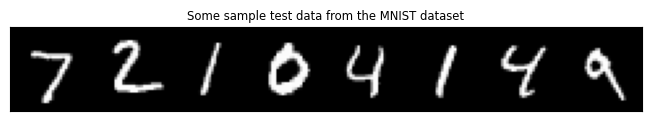

In [3]:
kwargs = {'num_workers': 1, 'pin_memory': True} if use_accel else {}
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True,
                   transform=transforms.ToTensor()),
    batch_size=batch_size, shuffle=True, **kwargs)
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transforms.ToTensor()),
    batch_size=batch_size, shuffle=False, **kwargs)

comparison_img_data: torch.Tensor = torchvision.utils.make_grid(next(iter(test_loader))[0][:8])


def show_grid_as_figure(imgs, existing_figure: plt.Figure = None, horizontal: bool = True, captions: Union[Sequence[str], None] = None, title: str = "") -> plt.Figure:
    if not isinstance(imgs, Sequence):
        #print(type(imgs))
        imgs = [imgs]
    fig: plt.Figure

    cols = len(imgs) if horizontal else 1
    rows = 1 if horizontal else len(imgs)
    fig, axs = (plt if existing_figure is None else existing_figure).subplots(ncols=cols, nrows=rows, layout="constrained", squeeze=False)
    #if existing_figure is None:
    #    plt.tight_layout()
    #else:
    #    fig.tight_layout()
    if title:
        fig.suptitle(title)

    #print(len(axs))
    #print(len(axs[0]))
    has_captions: bool = captions is not None and len(captions) >= len(imgs)
    for i, (img, ax) in enumerate(zip(imgs, axs.flat)):
        img = img.detach()
        img = torchvision.transforms.functional.to_pil_image(img)
        #ax: plt.Axes = axs[0, i] if horizontal else axs[i, 0]
        ax.imshow(np.asarray(img))
        ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
        if has_captions:
            ax.set_title(captions[i],fontsize="small")
    return fig


show_grid_as_figure(comparison_img_data,captions=["Some sample test data from the MNIST dataset"])

In [4]:

#show_grid_as_figure(list([comparison_img_data, comparison_img_data, comparison_img_data]), horizontal=False, captions=["de da", "de dum", "de do"],title="xd")



The model itself

In [5]:
class VAE(nn.Module):
    """
    A variational auto-encoder model.
    """
    def __init__(self, name: str, long_name: str = None):
        super(VAE, self).__init__()
        self.name: str = name
        self.long_name: str = long_name if long_name is not None else name
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 20)
        self.fc22 = nn.Linear(400, 20)
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)


    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def get_name(self) -> str:
        return self.name

    def get_long_name(self) -> str:
        return self.long_name

    def get_device(self) -> torch.device:
        return next(self.parameters()).device

    def get_dtype(self) -> torch.dtype:
        return next(self.parameters()).dtype


Creating the models and the optimizers

In [6]:

def get_model_32() -> tuple[VAE, optim.Optimizer]:
    model_32: VAE = VAE("adam_f32", long_name="float32, Adam optimizer").to(device=device, dtype=torch.float32)
    optimizer_32: optim.Optimizer = optim.Adam(model_32.parameters(), lr=1e-3)
    return model_32, optimizer_32

def get_model_w_32() -> tuple[VAE, optim.Optimizer]:
    model_w_32: VAE = VAE("adamW_f32", long_name="float32, AdamW optimizer").to(device=device, dtype=torch.float32)
    optimizer_w_32: optim.Optimizer = optim.AdamW(model_w_32.parameters(), lr=1e-3)
    return model_w_32, optimizer_w_32

def get_model_w_16() -> tuple[VAE, optim.Optimizer]:
    model_w_16: VAE = VAE("adamW_bf16", long_name="bfloat16, AdamW optimizer").to(device=device, dtype=torch.bfloat16)
    optimizer_w_16: optim.Optimizer = optim.AdamW(model_w_16.parameters(), lr=1e-3)
    return model_w_16, optimizer_w_16

def get_model_sr_16() -> tuple[VAE, optim.Optimizer]:
    model_sr_16: VAE = VAE("sr_adamW_bf16", long_name="bfloat16, Stochastic AdamW optimizer").to(device=device, dtype=torch.bfloat16)
    optimizer_sr_16: optim.Optimizer = torchastic.AdamW(model_sr_16.parameters(), lr=1e-3)
    return model_sr_16, optimizer_sr_16

The loss function

~~I'm still not entirely sure how it works~~

In [7]:
# Reconstruction + KL divergence losses summed over all elements and batch
def loss_function(recon_x, x, mu, logvar,
                  dtype: torch.dtype = torch.get_default_dtype()
    ):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    # https://arxiv.org/abs/1312.6114
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dtype=dtype)

    return torch.sum(BCE + KLD, dtype=dtype) #BCE + KLD


Dataclasses for storing the results of training/testing the models

In [8]:
@dataclass(init=True, frozen=True)
class EpochResult:
    """dataclass for the training results"""
    model_id: str
    epoch: int
    iteration: int
    train_loss: Number
    train_duration: float
    test_loss: Number

    comparison_fname: str
    result_fname: str

    @classmethod
    def make(cls, id: str, epoch: int, iteration: int, train_loss: Number, train_duration: float, test_loss: Number, comp_fname: str, result_fname: str, comp_img: Union[None, torch.Tensor] = None, result_img: Union[None, torch.Tensor] = None) -> "EpochResult":
        return cls(id, epoch, iteration, train_loss, train_duration, test_loss, comp_fname, result_fname)#, comp_img, result_img)

    @classmethod
    def from_json(cls, json_str: str) -> "EpochResult":
        data = json.decoder.JSONDecoder().decode(json_str)
        comp_image: Union[None, torch.Tensor] = None
        try:
            comp_image = decode_image(data["comparison_fname"])
        except Exception as e:
            print(f"Could not open comparison image {data["comparison_fname"]}", file=sys.stderr)
            print(e, file=sys.stderr)

        res_image: Union[None, torch.Tensor] = None
        try:
            res_image = decode_image(data["result_fname"])
        except Exception as e:
            print(f"Could not open result image {data["result_fname"]}", file=sys.stderr)
            print(e, file=sys.stderr)

        return cls.make(data["model_id"], data["epoch"], data["iteration"], data["train_loss"], data["train_duration"], data["test_loss"], data["comparison_fname"], data["result_fname"], comp_image, res_image)

    def json(self) -> str:
        return json.dumps({"model_id": self.model_id, "epoch": self.epoch, "iteration": self.iteration, "train_loss": self.train_loss, "train_duration": self.train_duration, "test_loss": self.test_loss, "comparison_fname": self.comparison_fname, "result_fname": self.result_fname}, sort_keys=True, indent=4)

    def __repr__(self) -> str:
        return f"EpochResult(model_id={self.model_id}, epoch={self.epoch}, iteration={self.iteration}, train_loss={self.train_loss}, train_duration={self.train_duration}, test_loss={self.test_loss}, comparison_fname={self.comparison_fname}, result_fname={self.result_fname})"

    @property
    def comparison_img(self) -> Union[None, torch.Tensor]:
        try:
            return decode_image(self.comparison_fname)
        except Exception as e:
            print(f"Could not open result image {self.comparison_fname}", file=sys.stderr)
            print(e, file=sys.stderr)
        return None

    def result_img(self) -> Union[None, torch.Tensor]:
        try:
            return decode_image(self.result_fname)
        except Exception as e:
            print(f"Could not open result image {self.result_fname}", file=sys.stderr)
            print(e, file=sys.stderr)
        return None


@dataclass(frozen=True, repr=True, init=True)
class IterationResult:
    """dataclass for the overall results of a model iteration"""
    epochs: tuple[EpochResult, ... ]
    "the per-epoch results of this iteration of the model"

    iteration: int

    model_file: str

    model_id: str
    model_full_name: str

    #def __init__(self, all_epochs: Sequence[EpochResult], model_file: str, model_name: str, model_full_name: str):
    #    self.epochs = tuple(all_epochs)
    #    self.model_file = model_file
    #    self.model_id = model_name
    #    self.model_full_name = model_full_name

    @classmethod
    def make(cls, all_epochs: Sequence[EpochResult], iteration_num: int, model: VAE, model_filename: str) -> "IterationResult":
        return cls(tuple(e for e in all_epochs), iteration_num, model_filename, model.get_name(), model.get_long_name())

    @cached_property
    def epoch_count(self) -> int:
        return len(self.epochs)

    def __iter__(self) -> Iterator[EpochResult]:
        return iter(self.epochs)

    @property
    def final_epoch(self) -> EpochResult:
        return self.epochs[-1]

    @property
    def train_durations(self) -> Iterator[float]:
        for e in self.epochs:
            yield e.train_duration
        return StopIteration

    @cached_property
    def overall_train_duration(self) -> float:
        return sum(self.train_durations)

    @property
    def train_losses(self) -> Iterator[Number]:
        for e in self.epochs:
            yield e.train_loss
        return StopIteration

    @property
    def test_losses(self) -> Iterator[Number]:
        for e in self.epochs:
            yield e.test_loss
        return StopIteration

    @cached_property
    def final_loss(self) -> Number:
        return self.final_epoch.test_loss

    @property
    def comparison_imgs(self) -> Iterator[torch.Tensor]:
        for e in self.epochs:
            yield torchvision.io.decode_image(e.comparison_fname)
        return StopIteration

    @property
    def result_imgs(self) -> Iterator[torch.Tensor]:
        for e in self.epochs:
            yield torchvision.io.decode_image(e.result_fname)
            #yield e.result_img
        return StopIteration

    @property
    def comparison_fnames(self) -> Iterator[str]:
        for e in self.epochs:
            yield e.comparison_fname
        return StopIteration

    @property
    def result_fnames(self) -> Iterator[str]:
        for e in self.epochs:
            yield e.result_fname
        return StopIteration

    def __len__(self) -> int:
        return len(self.epochs)

    def __getitem__(self, idx: int) -> EpochResult:
        for e in self.epochs:
            if e.epoch == idx:
                return e
        raise IndexError(f"Epoch {idx} does not exist. Consider querying the epochs tuple directly.")

    def json(self) -> str:
        return json.dumps({"iteration": self.iteration,"model_file": self.model_file, "model_id": self.model_id, "model_full_name": self.model_full_name, "epochs": tuple(e.json() for e in self.epochs)}, sort_keys=True, indent=4)

    @classmethod
    def from_json(cls, json_str: str) -> "IterationResult":
        data = json.decoder.JSONDecoder().decode(json_str)
        return cls(tuple(EpochResult.from_json(e) for e in data["epochs"]), data["iteration"], data["model_file"], data["model_id"], data["model_full_name"])

    @cached_property
    def comparison_image_figure(self) -> tuple[plt.Figure, str]:
        fig_title = f"Model {self.model_id} iteration {self.iteration} comparisons"
        fig_name = f"results/img/comp_{self.model_id}_{self.iteration}.png"
        return show_grid_as_figure(
            [comparison_img_data] + [e.comparison_img for e in self.epochs],
            horizontal=False,
            captions=["Originals"] + [f"Epoch #{e.epoch:2} recreation (loss: {e.test_loss:.3f})" for e in self.epochs],
            title=fig_title
        ), fig_name


@dataclass(frozen=True, repr=True, init=True)
class ModelResult:
    """dataclass for the overall results of a model for each iteration"""
    iterations: tuple[IterationResult, ... ]
    "the per-iteration results of the model"

    model_id: str
    model_full_name: str

    #def __init__(self, all_epochs: Sequence[EpochResult], model_file: str, model_name: str, model_full_name: str):
    #    self.epochs = tuple(all_epochs)
    #    self.model_file = model_file
    #    self.model_id = model_name
    #    self.model_full_name = model_full_name

    @classmethod
    def make(cls, all_iterations: Sequence[IterationResult], model: VAE) -> "ModelResult":
        return cls(tuple(it for it in all_iterations), model.get_name(), model.get_long_name())

    @cached_property
    def iteration_count(self) -> int:
        return len(self.iterations)

    @cached_property
    def epoch_count(self) -> int:
        return self.iterations[0].epoch_count

    def __iter__(self) -> Iterator[IterationResult]:
        return iter(self.iterations)

    @property
    def best_iteration_num(self) -> int:
        """returns the iteration number which had the lowest final loss (best overall fitness)"""
        lowest: Number = self.iterations[0].final_loss
        index: int = 1
        for it in self.iterations:
            if it.final_loss < lowest:
                lowest = it.final_loss
                index = it.iteration
        return index

    @property
    def final_losses(self) -> Iterator[Number]:
        for it in self.iterations:
            yield it.final_loss
        return StopIteration

    @property
    def overall_train_durations(self) -> Iterator[float]:
        for it in self.iterations:
            yield it.overall_train_duration
        return StopIteration

    @cached_property
    def overall_train_duration(self) -> float:
        return sum(it.overall_train_duration for it in self.iterations)


    @property
    def train_durations(self) -> Iterator[Iterator[float]]:
        for it in self.iterations:
            yield it.train_durations
        return StopIteration

    @property
    def train_losses(self) -> Iterator[Iterator[Number]]:
        for it in self.iterations:
            yield it.train_losses
        return StopIteration

    @property
    def test_losses(self) -> Iterator[Iterator[Number]]:
        for e in self.iterations:
            yield e.test_losses
        return StopIteration

    @property
    def comparison_image_figures(self) -> Iterator[tuple[plt.Figure, str]]:
        for it in self.iterations:
            yield it.comparison_image_figure
        return StopIteration

    @property
    def mean_final_loss(self) -> Number:
        return sum(self.final_losses)/self.iteration_count

    @property
    def mean_train_duration(self) -> Number:
        return self.overall_train_duration/self.iteration_count


    def __len__(self) -> int:
        return len(self.iterations)

    def __getitem__(self, idx: int) -> IterationResult:
        for it in self.iterations:
            if it.iteration == idx:
                return it
        raise IndexError(f"Iteration {idx} does not exist. Consider querying the iterations tuple directly.")

    @property
    def best_iteration(self) -> IterationResult:
        return self.__getitem__(self.best_iteration_num)

    def json(self) -> str:
        return json.dumps({"model_id": self.model_id, "model_full_name": self.model_full_name, "iterations": tuple(it.json() for it in self.iterations)}, sort_keys=True, indent=4)

    @classmethod
    def from_json(cls, json_str: str) -> "ModelResult":
        data = json.decoder.JSONDecoder().decode(json_str)
        return ModelResult(tuple(IterationResult.from_json(it) for it in data["iterations"]), data["model_id"], data["model_full_name"])



some helper methods for the graphs

In [9]:
def grid_stuff(ax: plt.Axes, both: bool = False, x: bool = False) -> None:
    """adds gridlines to the specified axes"""
    ax.grid(visible=True, which='major', color='#666666', linestyle='-', axis = "both" if both else ("x" if x else "y"))
    ax.grid(visible=True, which='minor', color='#999999', linestyle='--', axis = "both" if both else ("x" if x else "y"), alpha=0.6)
    return

def grid_stuff_fig(the_fig: plt.Figure, both: bool = False, x: bool = False) -> None:
    """adds gridlines to all axes in a given figure"""
    for ax in the_fig.get_axes():
        grid_stuff(ax, both)

def get_plt_colours() -> list[Any]:
    """obtains the standard colour cycle used by matplotlib"""
    return plt.rcParams['axes.prop_cycle'].by_key()['color']

def plt_cycler_train_test() -> Cycler[Any, ...]:
    """cycler of linestyles and colours for iterations.
    colour1 dashed, colour1 solid, colour2 dashed, colour2 dotted, etc...
    assumes that we plot 'train' then 'test' info for the given iteration"""
    #colours = []
    #for c in get_plt_colours():
    #    colours.append(c)
    #    colours.append(c)
    return cycler(color=get_plt_colours()) * cycler(linestyle=["dashed", "solid"])


Here's how I train the models

In [10]:
def train(epoch: int, model: VAE, optimizer: Optimizer) -> tuple[float, Number]:
    train_loss: Number = 0
    start_time: float = perf_counter()
    model.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device=device, dtype=model.get_dtype())
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar, dtype=model.get_dtype())
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        #if batch_idx % log_interval == 0 and batch_idx > 0:
        #    print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        #        epoch, batch_idx * len(data), len(train_loader.dataset),
        #        100. * batch_idx / len(train_loader),
        #        loss.item() / len(data)))
    end_time: float = perf_counter()
    duration: float = end_time - start_time
    avg_loss: Number = train_loss / len(train_loader.dataset)
    #print('====> Epoch: {} Average loss: {:.4f}'.format(epoch, avg_loss))
    return duration, avg_loss


And here's how the models get tested

In [11]:

def test(epoch: int, iteration: int, model: VAE, optimizer: Optimizer) -> tuple[Number, str, torch.Tensor, str] :
    model.eval()
    test_loss: Number = 0
    comp_fname: str = 'results/img/reconstruction_' + str(epoch) + '_' + str(model.get_name()) + '_'+ str(iteration) +'.png'
    comp_img: torch.Tensor = torch.empty(0)
    comp_epoch: str = ""
    with torch.no_grad():
        for i, (data, _) in enumerate(test_loader):
            data = data.to(device=device)#, dtype=model.get_dtype())
            recon_batch, mu, logvar = model(data.to(device=device, dtype=model.get_dtype(), copy=True))
            test_loss += loss_function(recon_batch.to(device=device, dtype=torch.get_default_dtype()), data.to(device=device, dtype=torch.get_default_dtype()), mu, logvar).item()
            if i == 0:
                n = min(data.size(0), 8)
                #comp_img = 'results/reconstruction_' + str(epoch) + '_' + str(model.get_name()) +  '.png'
                comparison = torchvision.utils.make_grid(
                    recon_batch.view(batch_size, 1, 28, 28)[:n]
                    #torch.cat([data[:n],
                    #     recon_batch.view(batch_size, 1, 28, 28)[:n]]
                    #)
                )
                save_image(comparison.cpu(),
                         comp_fname, nrow=n)
                comp_epoch = str(epoch)

    test_loss /= len(test_loader.dataset)
    print('====> Epoch {:d} Test set loss: {:.4f}  {:s}'.format(epoch, test_loss, model.get_name()))
    return test_loss, comp_fname, comp_img, comp_epoch

Function for testing and training the models, along with producing the raw data and cool graphs for that model

In [12]:
generator_sample: torch.Tensor = torch.randn(64, 20, device=torch.device("cpu"))

def test_and_train(model_optim_getter: Callable[[], tuple[VAE, optim.Optimizer]]) -> tuple[ModelResult, plt.Figure]:
    images: list[torch.Tensor] = []
    captions: list[str] = []



    fig: plt.Figure = plt.figure(figsize=(10, 4))
    plt.xlabel("epoch")
    plt.ylabel("loss")

    plt.xticks(np.arange(epochs), np.arange(1, epochs+1))

    iteration_results: list[IterationResult] = []

    fig_colours = get_plt_colours()
    colour_iter = iter(fig_colours)

    model: VAE = None
    optimizer: optim.Optimizer = None
    #fig_scale : float = 2
    #plt.figure(figsize=(0.5+(2*fig_scale),0.25+(epochs * fig_scale)))
    #plt.title(f"Epoch outputs for model {str(model.get_name())}")

    key_malarkey: list[plt.Line2D] = []

    for iteration_num in range(1, iterations+1):
        print(f"== Iteration {iteration_num:2d} of {iterations:2d} ==")

        epoch_results: list[EpochResult] = []
        model, optimizer = model_optim_getter()

        for epoch in range(1, epochs + 1):
            train_duration, train_loss = train(epoch, model, optimizer)
            test_loss, comp_fname, comp_img, comp_epoch = test(epoch, iteration_num, model, optimizer)

            res_img: torch.Tensor
            res_fname: str = 'results/img/sample_' + str(epoch) + '_' + str(model.get_name()) + '_' + str(iteration_num) + '.png'
            if comp_img is not None:
                pass
                #plt.subplot(epochs, 2 ,(2*epoch)-1)
                #plt.imshow(comp_img.to(device=device, dtype=torch.get_default_dtype()), cmap=plt.get_cmap('gray'))
                #plt.xticks([])
                #plt.yticks([])
                #plt.grid(False)
                #plt.xlabel("comparison, epoch {:s}, loss {:.4f}".format(comp_epoch, loss))


            with torch.no_grad():
                sample = generator_sample.to(device=device, dtype=model.get_dtype(), copy=True)
                sample = model.decode(sample).cpu()
                #res_fname = 'results/sample_' + str(epoch) + '_' + str(model.get_name()) + '.png'

                #save_image(sample.view(64, 1, 28, 28),
                #           'results/sample_' + str(epoch) + '_' + str(model.get_name()) + '.png')
                #images.append(sample.view(64,1,28,28))
                res_img = torchvision.utils.make_grid(sample.view(64,1,28,28), nrow=8)
                save_image(res_img, res_fname)
                captions.append(f"epoch {str(epoch)}")

                #plt.subplot(epochs,2,2*epoch)
                #plt.imshow(sample.view(64, 1, 28, 28).permute(0,2,3,1).reshape(28 * 8, 28 * 8, 1).to(device=device, dtype=torch.get_default_dtype()), cmap=plt.get_cmap('gray'))
                #plt.xticks([])
                #plt.yticks([])
                #plt.grid(False)
                #plt.xlabel("epoch {:f}, test set loss {:.4f}".format(epoch, loss))
            epoch_results.append(EpochResult.make(model.get_name(), epoch, iteration_num, train_loss, train_duration, test_loss, comp_fname=comp_fname, result_fname=res_fname, comp_img=comp_img, result_img=res_img))

        model_fname: str = 'models/' + str(model.get_name()) + '_' + str(iteration_num) + '.pt'
        torch.save(model.state_dict(), model_fname)

        it_result = IterationResult.make(epoch_results, iteration_num, model, model_fname)

        line_colour = next(colour_iter)#, default=tuple(random.random(), random.random(), random.random()))

        #tr_plot = None
        #if iteration_num == 1:
        tr_plot, = plt.plot(tuple(it_result.train_losses), label=f"train loss (run {iteration_num})", color=line_colour, linestyle='dashed')
        #else:
        #    tr_plot, = ax.plot(tuple(it_result.train_losses), color=line_colour, linestyle='dashed') # not bothering with a label for training lines after iteration 1
        test_plot, = plt.plot(tuple(it_result.test_losses), label=f"test loss (run {iteration_num})", color=line_colour, linestyle='solid')
        if iteration_num == 1:
            key_malarkey.append(tr_plot)
        key_malarkey.append(test_plot)
        iteration_results.append(it_result)

    key_names = list(f"train/test loss run {i}" for i in range(1, iterations+1))

    fig.legend(handles=key_malarkey, #numpoints=1, #handler_map={tuple: HandlerTuple(ndivide=None)},
        bbox_to_anchor=(1.05, 1), loc='outside right upper', borderaxespad=0., prop={'size': 11})

    grid_stuff_fig(fig, both=False)

    results: ModelResult = ModelResult.make(iteration_results, model)

    plt.title(f"per-epoch results for model {str(model.get_name())} ({str(results.iteration_count)} iterations)")
    #fig.show()

    return results, fig
    #plt.show()



And now, testing/training the models and storing the results

<IPython.core.display.Javascript object>

== Iteration  1 of 10 ==
====> Epoch 1 Test set loss: 127.3883  adam_f32
====> Epoch 2 Test set loss: 115.8581  adam_f32
====> Epoch 3 Test set loss: 111.8350  adam_f32
====> Epoch 4 Test set loss: 109.7967  adam_f32
====> Epoch 5 Test set loss: 108.8510  adam_f32
====> Epoch 6 Test set loss: 107.5599  adam_f32
====> Epoch 7 Test set loss: 107.1193  adam_f32
====> Epoch 8 Test set loss: 106.3668  adam_f32
====> Epoch 9 Test set loss: 105.9815  adam_f32
====> Epoch 10 Test set loss: 105.5395  adam_f32
== Iteration  2 of 10 ==
====> Epoch 1 Test set loss: 127.1519  adam_f32
====> Epoch 2 Test set loss: 115.7341  adam_f32
====> Epoch 3 Test set loss: 111.8901  adam_f32
====> Epoch 4 Test set loss: 109.8746  adam_f32
====> Epoch 5 Test set loss: 108.6839  adam_f32
====> Epoch 6 Test set loss: 107.5392  adam_f32
====> Epoch 7 Test set loss: 107.1380  adam_f32
====> Epoch 8 Test set loss: 106.2585  adam_f32
====> Epoch 9 Test set loss: 105.9050  adam_f32
====> Epoch 10 Test set loss: 105.605

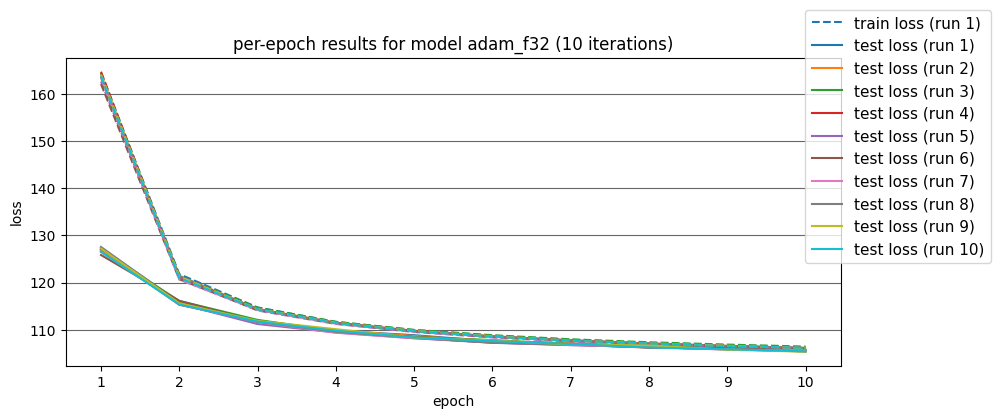

In [13]:
results_adam_32: ModelResult
results_adam_32, fig_adam_32 = test_and_train(get_model_32)

#fig_adam_32.show()
fig_adam_32

<IPython.core.display.Javascript object>

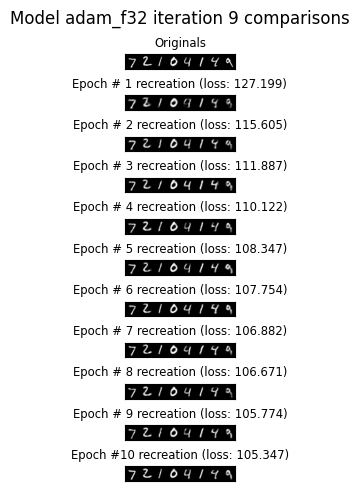

In [14]:
fig, figname = results_adam_32.best_iteration.comparison_image_figure

fig.savefig(figname)

fig

In [15]:
json.dump(results_adam_32.json(), open("results/adam_f32.json", "w"))

In [16]:
pickle.dump(results_adam_32, open("results/adam_f32.pkl", "wb"))

<IPython.core.display.Javascript object>

== Iteration  1 of 10 ==
====> Epoch 1 Test set loss: 127.4536  adamW_f32
====> Epoch 2 Test set loss: 116.0220  adamW_f32
====> Epoch 3 Test set loss: 112.1286  adamW_f32
====> Epoch 4 Test set loss: 110.3600  adamW_f32
====> Epoch 5 Test set loss: 108.7452  adamW_f32
====> Epoch 6 Test set loss: 108.0847  adamW_f32
====> Epoch 7 Test set loss: 107.1610  adamW_f32
====> Epoch 8 Test set loss: 106.7881  adamW_f32
====> Epoch 9 Test set loss: 106.2277  adamW_f32
====> Epoch 10 Test set loss: 105.9809  adamW_f32
== Iteration  2 of 10 ==
====> Epoch 1 Test set loss: 125.9533  adamW_f32
====> Epoch 2 Test set loss: 115.6049  adamW_f32
====> Epoch 3 Test set loss: 111.5469  adamW_f32
====> Epoch 4 Test set loss: 109.5030  adamW_f32
====> Epoch 5 Test set loss: 108.2241  adamW_f32
====> Epoch 6 Test set loss: 107.5786  adamW_f32
====> Epoch 7 Test set loss: 106.8604  adamW_f32
====> Epoch 8 Test set loss: 106.2856  adamW_f32
====> Epoch 9 Test set loss: 105.9126  adamW_f32
====> Epoch 10 Tes

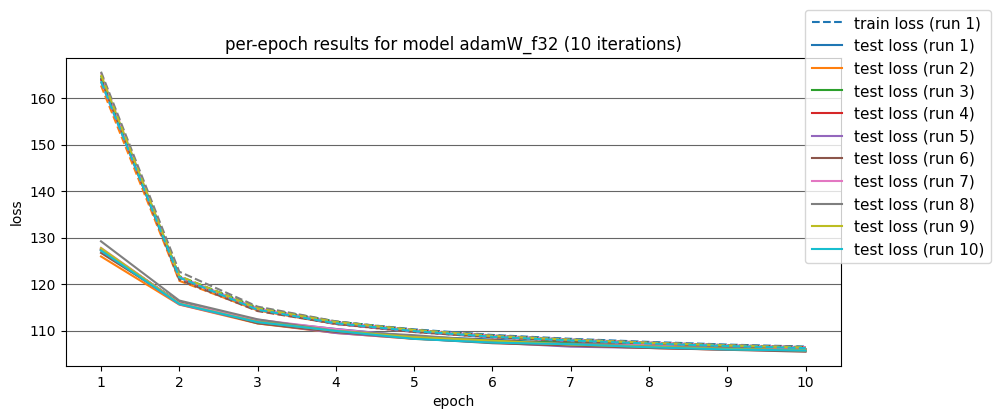

In [17]:
results_adamw_32: ModelResult
results_adamw_32, fig_adamw_32 = test_and_train(get_model_w_32)

fig_adamw_32#.show()

<IPython.core.display.Javascript object>

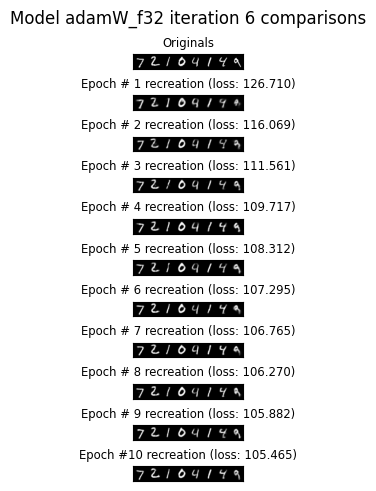

In [18]:
fig, figname = results_adamw_32.best_iteration.comparison_image_figure

fig.savefig(figname)

fig

In [19]:
json.dump(results_adamw_32.json(), open("results/adamw_f32.json", "w"))

In [20]:
pickle.dump(results_adamw_32, open("results/adamw_f32.pkl", "wb"))

<IPython.core.display.Javascript object>

== Iteration  1 of 10 ==
====> Epoch 1 Test set loss: 131.6601  adamW_bf16
====> Epoch 2 Test set loss: 120.4635  adamW_bf16
====> Epoch 3 Test set loss: 117.0958  adamW_bf16
====> Epoch 4 Test set loss: 115.2320  adamW_bf16
====> Epoch 5 Test set loss: 114.1134  adamW_bf16
====> Epoch 6 Test set loss: 113.3046  adamW_bf16
====> Epoch 7 Test set loss: 112.7202  adamW_bf16
====> Epoch 8 Test set loss: 112.3063  adamW_bf16
====> Epoch 9 Test set loss: 112.0006  adamW_bf16
====> Epoch 10 Test set loss: 111.6699  adamW_bf16
== Iteration  2 of 10 ==
====> Epoch 1 Test set loss: 132.5450  adamW_bf16
====> Epoch 2 Test set loss: 120.9608  adamW_bf16
====> Epoch 3 Test set loss: 116.9843  adamW_bf16
====> Epoch 4 Test set loss: 115.2248  adamW_bf16
====> Epoch 5 Test set loss: 114.0696  adamW_bf16
====> Epoch 6 Test set loss: 113.5170  adamW_bf16
====> Epoch 7 Test set loss: 112.6452  adamW_bf16
====> Epoch 8 Test set loss: 112.3011  adamW_bf16
====> Epoch 9 Test set loss: 111.9099  adamW_bf16

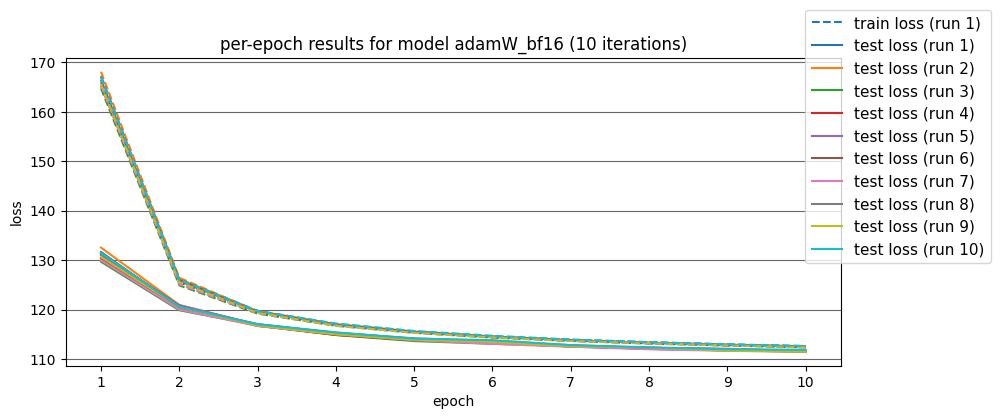

In [21]:
results_adamw_16: ModelResult
results_adamw_16, fig_adamw_16 = test_and_train(get_model_w_16)

fig_adamw_16#.show()

<IPython.core.display.Javascript object>

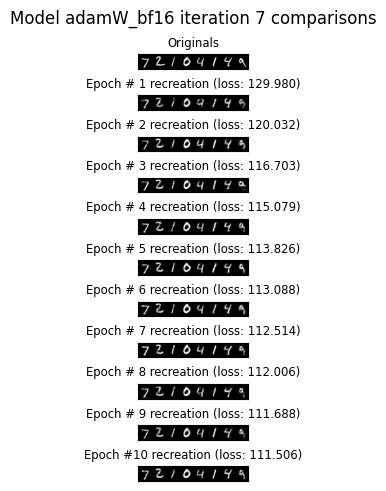

In [22]:
fig, figname = results_adamw_16.best_iteration.comparison_image_figure

fig.savefig(figname)

fig

In [23]:
json.dump(results_adamw_16.json(), open("results/adamw_bf16.json", "w"))

In [24]:
pickle.dump(results_adamw_16, open("results/adamw_bf16.pkl", "wb"))

In [25]:
results_adamw_16.best_iteration_num

7

<IPython.core.display.Javascript object>

== Iteration  1 of 10 ==
====> Epoch 1 Test set loss: 126.8040  sr_adamW_bf16
====> Epoch 2 Test set loss: 115.5756  sr_adamW_bf16
====> Epoch 3 Test set loss: 111.8457  sr_adamW_bf16
====> Epoch 4 Test set loss: 109.6986  sr_adamW_bf16
====> Epoch 5 Test set loss: 108.5321  sr_adamW_bf16
====> Epoch 6 Test set loss: 107.8823  sr_adamW_bf16
====> Epoch 7 Test set loss: 107.1409  sr_adamW_bf16
====> Epoch 8 Test set loss: 106.7104  sr_adamW_bf16
====> Epoch 9 Test set loss: 106.0218  sr_adamW_bf16
====> Epoch 10 Test set loss: 105.7700  sr_adamW_bf16
== Iteration  2 of 10 ==
====> Epoch 1 Test set loss: 127.1249  sr_adamW_bf16
====> Epoch 2 Test set loss: 115.8324  sr_adamW_bf16
====> Epoch 3 Test set loss: 112.0944  sr_adamW_bf16
====> Epoch 4 Test set loss: 109.9360  sr_adamW_bf16
====> Epoch 5 Test set loss: 108.9828  sr_adamW_bf16
====> Epoch 6 Test set loss: 107.8617  sr_adamW_bf16
====> Epoch 7 Test set loss: 107.2461  sr_adamW_bf16
====> Epoch 8 Test set loss: 106.6973  sr_adamW_

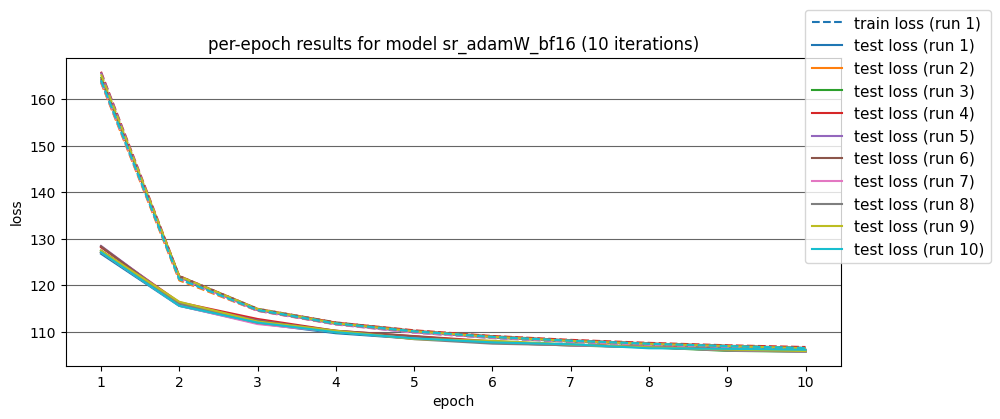

In [26]:
results_sr_16: ModelResult
results_sr_16, fig_sr_16 = test_and_train(get_model_sr_16)

fig_sr_16#.show()

<IPython.core.display.Javascript object>

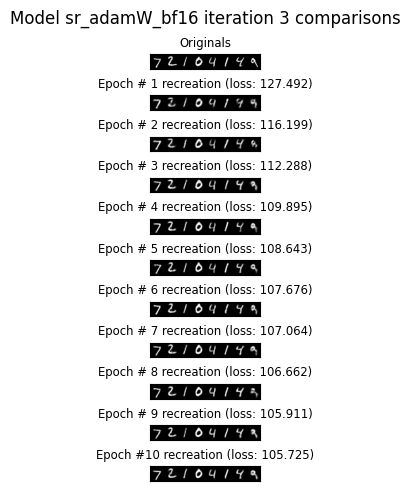

In [27]:
fig, figname = results_sr_16.best_iteration.comparison_image_figure

fig.savefig(figname)

fig

In [28]:
json.dump(results_sr_16.json(), open("results/sr_adamw_bf16.json", "w"))

In [29]:
pickle.dump(results_sr_16, open("results/sr_adamw_bf16.pkl", "wb"))

# Comparing the trained models to each other


Some code to load the pickled results files
(so I don't need to spend hours re-running _everything_ in order to fix the graphs)

In [30]:
def load_the_results(fname: str, val) -> ModelResult:
    try:
        if not val:
            print(f"results probably missing, recovering from {fname}...")
            with open(fname, "rb") as f:
                val = pickle.load(f)
        else:
            print("looks like the results exist, carry on.")
    except NameError:
        with open(fname, "rb") as f:
            val = pickle.load(f)
    return val

results_adam_32: ModelResult
results_adam_32 = load_the_results("results/adam_f32.pkl", results_adam_32)
results_adamw_32: ModelResult
results_adamw_32 = load_the_results("results/adamw_f32.pkl", results_adamw_32)
results_adamw_16: ModelResult
results_adamw_16 = load_the_results("results/adamw_bf16.pkl", results_adamw_16)
results_sr_16: ModelResult
results_sr_16 = load_the_results("results/sr_adamw_bf16.pkl", results_sr_16)

#with open("results/adamw_16.json", "r") as f:
#    results_adamw_16 = ModelResult.from_json(json.load(f))

#with open("results/sr_adamw_16.json", "r") as f:
#    results_sr_16 = ModelResult.from_json(json.load(f))

#print(repr(results_adamw_16))
#print(repr(results_sr_16))

#pickle.dump(results_adamw_16, open("results/adamw_bf16.pkl", "wb"))
#pickle.dump(results_sr_16, open("results/sr_adamw_bf16.pkl", "wb"))

#results_sr_16 = load_the_results("results/sr_adamw_bf16.pkl", results_sr_16)



looks like the results exist, carry on.
looks like the results exist, carry on.
looks like the results exist, carry on.
looks like the results exist, carry on.


In [31]:
results_dict: dict[str, ModelResult] = {
    "baseline (float32 adam)": results_adam_32,
    "float32 adamw": results_adamw_32,
    "bfloat16 adamw": results_adamw_16,
    "stochastic bfloat16 adamw": results_sr_16,
}

<IPython.core.display.Javascript object>

Final test loss for each iteration of each model:
name            |run #|Loss (lower = better!)
----------------|-----|----------------------
adam_f32        |   1 | 105.539528
adam_f32        |   2 | 105.605212
adam_f32        |   3 | 105.790052
adam_f32        |   4 | 105.537616
adam_f32        |   5 | 105.517410
adam_f32        |   6 | 105.447329
adam_f32        |   7 | 105.641390
adam_f32        |   8 | 105.400155
adam_f32        |   9 | 105.346590
adam_f32        |  10 | 105.427330
adamW_f32       |   1 | 105.980874
adamW_f32       |   2 | 106.014252
adamW_f32       |   3 | 105.909065
adamW_f32       |   4 | 105.783132
adamW_f32       |   5 | 105.619453
adamW_f32       |   6 | 105.464527
adamW_f32       |   7 | 105.918842
adamW_f32       |   8 | 105.642592
adamW_f32       |   9 | 105.771234
adamW_f32       |  10 | 105.721504
adamW_bf16      |   1 | 111.669859
adamW_bf16      |   2 | 111.603153
adamW_bf16      |   3 | 111.555813
adamW_bf16      |   4 | 111.529569
adamW_bf16      | 

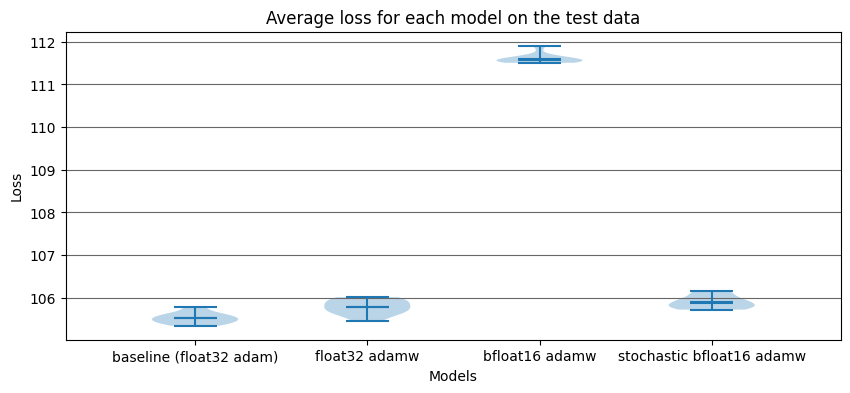

In [32]:



fig_loss: plt.Figure = plt.figure(figsize=(10, 4))

#final_losses: list[Number] = [res[epochs].fi for res in results_dict.values()]

violin1 = plt.violinplot([[l for l in res.final_losses] for res in results_dict.values()],
               showmeans=True, showextrema=True, showmedians=True)



ax_loss: plt.Axes = fig_loss.get_axes()[0]
grid_stuff(ax_loss)
ax_loss.set_xticks(np.arange(1, len(results_dict.keys()) + 1), labels=results_dict.keys())
ax_loss.set_xlim(0.25, len(results_dict.keys()) + 0.75)


#bars1 = plt.bar(results_dict.keys(), final_losses, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
#plt.bar_label(bars1)
plt.title("Average loss for each model on the test data")
ax_loss: plt.Axes = fig_loss.get_axes()[0]
grid_stuff(ax_loss)
ax_loss.set_ylabel("Loss")
ax_loss.set_xlabel("Models")

print("Final test loss for each iteration of each model:")
print(f"{'name':16}|{'run #':5}|Loss (lower = better!)")
print(f"{'-'*16}|{'-'*5}|{'-'*22}")
for name, res in results_dict.items():
    for the_iter in res.iterations:
        print(f"{res.model_id:16}|{the_iter.iteration:4d} | {the_iter.final_loss:f}")

fig_loss

<IPython.core.display.Javascript object>

Training duration for each iteration of each model:
name            |run #|Time taken (seconds) (lower = better!)
----------------|-----|----------------------
adam_f32        |   1 | 67.048532
adam_f32        |   2 | 61.706601
adam_f32        |   3 | 61.864635
adam_f32        |   4 | 61.973547
adam_f32        |   5 | 61.729428
adam_f32        |   6 | 61.709069
adam_f32        |   7 | 61.756885
adam_f32        |   8 | 61.720400
adam_f32        |   9 | 61.893674
adam_f32        |  10 | 61.843256
adamW_f32       |   1 | 69.643823
adamW_f32       |   2 | 62.909590
adamW_f32       |   3 | 61.961901
adamW_f32       |   4 | 62.415161
adamW_f32       |   5 | 61.750785
adamW_f32       |   6 | 61.962221
adamW_f32       |   7 | 62.003563
adamW_f32       |   8 | 62.026099
adamW_f32       |   9 | 61.978947
adamW_f32       |  10 | 63.011084
adamW_bf16      |   1 | 65.152389
adamW_bf16      |   2 | 63.967215
adamW_bf16      |   3 | 62.392349
adamW_bf16      |   4 | 62.793825
adamW_bf16      |   5 | 

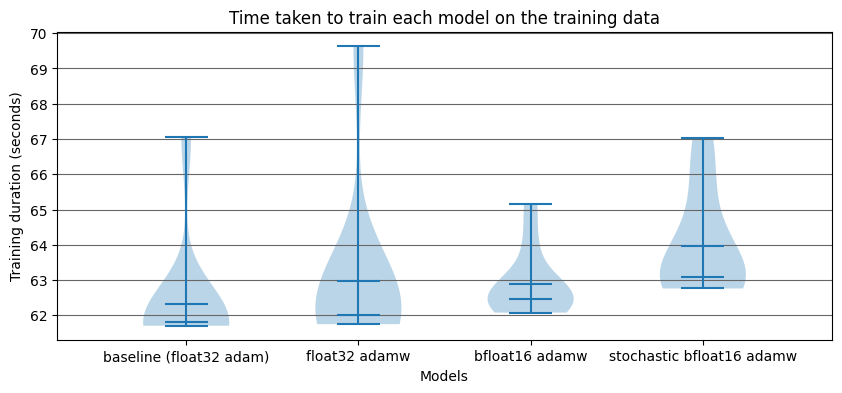

In [33]:


## Bar chart of time taken for training each model
fig_time: plt.Figure = plt.figure(figsize=(10, 4))

#training_times: list[float] = [sum(epoch.train_duration for epoch in info) for info in results_dict.values()]
#bars2 = plt.bar(results_dict.keys(), training_times, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
#plt.bar_label(bars2)

violin2 = plt.violinplot([[t for t in res.overall_train_durations] for res in results_dict.values()],
               showmeans=True, showextrema=True, showmedians=True)

plt.title("Time taken to train each model on the training data")
ax_time: plt.Axes = fig_time.get_axes()[0]
grid_stuff(ax_time)
ax_time.set_xticks(np.arange(1, len(results_dict.keys()) + 1), labels=results_dict.keys())
ax_time.set_xlim(0.25, len(results_dict.keys()) + 0.75)

ax_time.set_ylabel("Training duration (seconds)")
ax_time.set_xlabel("Models")

print("Training duration for each iteration of each model:")
print(f"{'name':16}|{'run #':5}|Time taken (seconds) (lower = better!)")
print(f"{'-'*16}|{'-'*5}|{'-'*22}")
for name, res in results_dict.items():
    for the_iter in res.iterations:
        print(f"{res.model_id:16}|{the_iter.iteration:4d} | {the_iter.overall_train_duration:f}")

fig_time

graphing training time vs overall loss

<IPython.core.display.Javascript object>

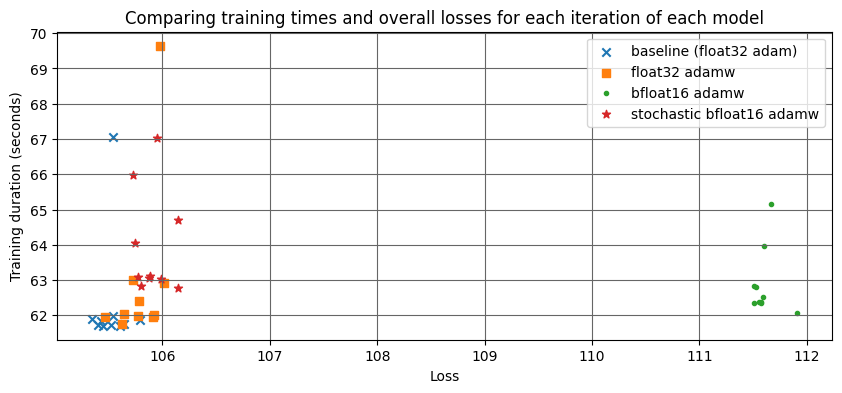

In [34]:

fig_loss_time = plt.figure(figsize=(10, 4))
ax_loss_time = fig_loss_time.subplots(1,1)

for (rname, res), colour, marker in zip(results_dict.items(), get_plt_colours(), ["x","s",".","*"]):
    ax_loss_time.scatter([l for l in res.final_losses], [t for t in res.overall_train_durations], c=colour, label=rname, marker=marker)

grid_stuff(ax_loss_time, both=True)
ax_loss_time.set_ylabel("Training duration (seconds)")
ax_loss_time.set_xlabel("Loss")
ax_loss_time.legend()

plt.title("Comparing training times and overall losses for each iteration of each model")

fig_loss_time


Did the stochastic float16 model provide a better result than the non-stochastic bfloat16 model?

In [35]:
sr_bfloat16_loss = results_sr_16.mean_final_loss
bfloat16_loss = results_adamw_16.mean_final_loss

if sr_bfloat16_loss < bfloat16_loss:
    print("The stochastic bfloat16 model was more accurate than the non-stochastic bfloat16 model!")
    print("Hypothesis 1 supported!")
else:
    print("The non-stochastic bfloat16 model was more accurate than the stochastic version!")
    print("Hypothesis 1 debunked!")

print("")
print(f"mean stochastic loss: {sr_bfloat16_loss}")
print(f"mean non-stochastic:  {bfloat16_loss}")

The stochastic bfloat16 model was more accurate than the non-stochastic bfloat16 model!
Hypothesis 1 supported!

mean stochastic loss: 105.90342922851562
mean non-stochastic:  111.60202364868164


Did the stochastic bfloat16 model have the shortest training time?

In [36]:
model_time_res: list[ModelResult] = [results_adam_32, results_adamw_32, results_adamw_16, results_sr_16]

model_time_res.sort(key=lambda res: res.mean_train_duration)

print("== training durations ==")
print(f"{'model id':16}: avg training duration (seconds)")
for m in model_time_res:
    print(f"{m.model_id:16}: {m.mean_train_duration}")

print("")
if model_time_res[0].model_id == results_sr_16.model_id:
    print("The stochastic rounding had the fastest training time!")
    print("\tHypothesis 2 supported!")
else:
    print("The stochastic rounding model didn't have the fastest training time!")
    print("\tHypothesis 2 debunked!")


== training durations ==
model id        : avg training duration (seconds)
adam_f32        : 62.324602709499956
adamW_bf16      : 62.88429997989952
adamW_f32       : 62.96631734600196
sr_adamW_bf16   : 63.96494253679848

The stochastic rounding model didn't have the fastest training time!
	Hypothesis 2 debunked!


Was the overall loss of the stochastic bfloat16 model no more than 1% higher than the worst float32 model?

In [37]:
worst_float32_loss = max(results_adam_32.mean_final_loss, results_adamw_32.mean_final_loss)
sr_bfloat16_loss = results_sr_16.mean_final_loss
bfloat16_loss = results_adamw_16.mean_final_loss


if sr_bfloat16_loss <= (worst_float32_loss * 1.01):
    print("The stochastic loss is no more than 1% higher than the worst float32 model!")
    print("\tHypothesis 3.1 supported!")
else:
    print("The stochastic model's loss is over 1% higher than the worse float32 model!")
    print("\tHypothesis 3.1 debunked!")

print("")

print(f"it is only {(sr_bfloat16_loss-worst_float32_loss)/worst_float32_loss}% worse")
print(f"stochastic: {sr_bfloat16_loss}")
print(f"worst f32:  {worst_float32_loss}")
print(f"difference: {(sr_bfloat16_loss-worst_float32_loss)} more loss in bfloat16 (lower = bfloat16 did better)")

print("")

midpoint_between_losses = (worst_float32_loss + bfloat16_loss)/2
if sr_bfloat16_loss < midpoint_between_losses:
    print("stochastic loss is closer to the float32 losses than the non-stochastic bfloat16 loss")
    print("\tHypothesis 3.2 supported!")
else:
    print("stochastic loss is closer to non-stochastic bfloat16 loss to the float32 losses")
    print("\tHypothesis 3.2 debunked!")

print("")
print("== all test data loss results ==")
print(f"{'model id':16}| mean final test loss (lower = better)")
for m in [results_adam_32, results_adamw_32, results_adamw_16, results_sr_16]:
    print(f"{m.model_id:16}| {m.mean_final_loss}")


The stochastic loss is no more than 1% higher than the worst float32 model!
	Hypothesis 3.1 supported!

it is only 0.0011427382686029933% worse
stochastic: 105.90342922851562
worst f32:  105.7825474633789
difference: 0.12088176513671556 more loss in bfloat16 (lower = bfloat16 did better)

stochastic loss is closer to the float32 losses than the non-stochastic bfloat16 loss
	Hypothesis 3.2 supported!

== all test data loss results ==
model id        | mean final test loss (lower = better)
adam_f32        | 105.52526109619141
adamW_f32       | 105.7825474633789
adamW_bf16      | 111.60202364868164
sr_adamW_bf16   | 105.90342922851562
